1 player: hard coaded matrix tak jak w 02


2 player uczy sie strategii pierwszego przez update w bayesian Theorem i chce odgadnac tranzition matrix 1 gracza
jak bedzie mial jego matrix to wtedy np gdy rock bedzie kolejny wg matrix wymienai rock->paper zeby wygrac z predykcja
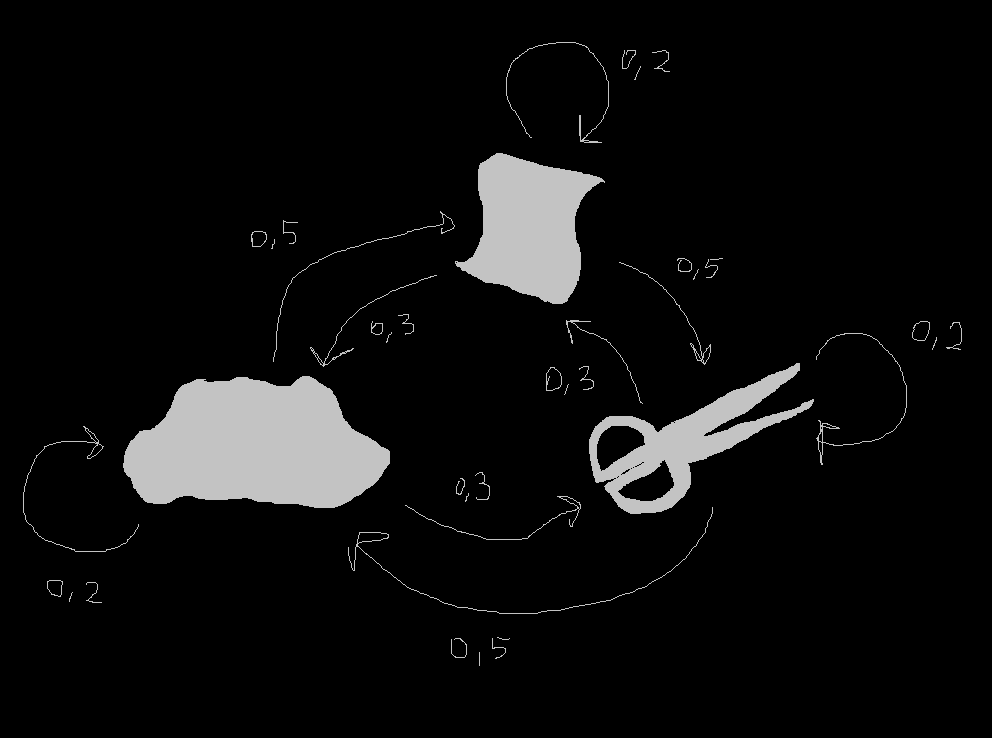

In [2]:
import numpy as np
"""
po przegranej/wygranej updatuje prawdopodobienstwa
for win +1, for lose -1 for draw 0
"""

'\npo przegranej/wygranej updatuje prawdopodobienstwa\nfor win +1, for lose -1 for draw 0\n'

Hard Coding pierwszego gracza (prawdopodobienstwa wg obrazka)

In [1]:
Hidden_States = ["Rock", "Paper", "Scissors"]

#poczatkowy wybor
initialStateDistribution = {
    "Rock": 1/3,
    "Paper": 1/3,
    "Scissors": 1/3
}

#kazdy kolejny
transitionMatrix = {
    "Rock":{"Rock": 0.2, "Paper": 0.5, "Scissors":0.3},
    "Paper":{"Paper":0.2, "Scissors": 0.5, "Rock":0.3},
    "Scissors":{"Scissors":0.2, "Rock":0.5, "Paper":0.3}
}

wyciagniecie wartosci z dict

In [3]:
def sampleFromDict(probabilityDict):
  #klucze -> wynik
  keys = list(probabilityDict.keys())

  #wartosci -> prawdopodobienstwo
  values = list(probabilityDict.values())

  return np.random.choice(keys, p=values)

symulacja ruchu 1 gracza (testowo)

In [24]:
state = sampleFromDict(initialStateDistribution)

print("nr state -> choice")

def ruch1Gracz(state):
  nextState = sampleFromDict(transitionMatrix[state])
  # print(nr, " ", state, "->", nextState)
  return nextState

for nr in range(10):
  state = ruch1Gracz(state)

nr state -> choice


ruchy 2 gracza:

P(A|B) gdzie A - nastepny, B - obecny ruch

Bayes: P(A|B) = (P(B|A)*P(A))/P(B)

In [64]:
#wystawianie najbarziej prawdopodobnych wyborow

moves = ["Rock", "Paper", "Scissors"]

#zliczenie przejsc (tworzy sie dict taki jak transitionMatrix dla 1 gracza tylko ze nie prawdopodobienstw tylko wykorzystan)
transitionCounts = {
    m1: {m2: 1 for m2 in moves} for m1 in moves
}

def updateCounts(previousMove, nextMove):
  transitionCounts[previousMove][nextMove] += 1 #update wykonanego ruchu


In [65]:
def BayesTheorem(currentMove):
  probabilities = {}

  #P(A)
  sumaPrawdopodobienstw = sum(
      transitionCounts[m1][m2] for m1 in moves for m2 in moves
  )#suma pojawien dla kazdego ruchu

  prawdopodobienstwoNext = {
      m: sum(transitionCounts[x][m] for x in moves) / sumaPrawdopodobienstw
      for m in moves
  }#dla kazdego ruchu jak czesto sie pojawial jak na razie

  #P(B)
  sumaObecnychPrawdop = sum(transitionCounts[currentMove].values())
  prawdopodobienstwoCurrent = sumaObecnychPrawdop / sumaPrawdopodobienstw

  for nextMove in moves:
    #P(B|A)
    pCurrentNext = (
        transitionCounts[currentMove][nextMove] /
        sum(transitionCounts[x][nextMove] for x in moves)
    )#jakie jest prawdopodobienstwo na obecny ruch(zalozony przez nas) pod warunkim ze wystapil kolejny(wylosowany)

    #Bayes
    probabilities[nextMove] = (
        pCurrentNext * prawdopodobienstwoNext[nextMove] / prawdopodobienstwoCurrent
    )#dla kazdego ruchu prawdopodobienstwo bayesem wystapienia go

  return probabilities#prawdopodobienstwo nastepnego jesli znamy obecny w formacie
  #{Rock: 0.2, Paper: 0.8, Scissors: 0}, tu wybor padnie na papier

wybor najlepszego ruchu na przewidziany

In [61]:
def counterMovePlayer2(predicted):
  if predicted == "Rock":
    return "Paper"
  elif predicted == "Paper":
    return "Scissors"
  else:
    return "Rock"

ruchy 2 gracza

In [62]:
def ruch2gracza(currentMove):
  probabilities = BayesTheorem(currentMove=currentMove)

  predicted = max(probabilities, key=probabilities.get)
  counter = counterMovePlayer2(predicted)

  return counter

SYMULACJA

In [84]:
state = sampleFromDict(initialStateDistribution)
statistics = {
    "Gracz1":0,
    "Gracz2":0,
    "remis":0
}
wins1Forpyplot = []
wins2Forpyplot = []

for rundaNr in range (1000):
  #gracz 1
  gracz1State = ruch1Gracz(state)

  #gracz 2
  gracz2State = ruch2gracza(state)

  #update gracz 2
  updateCounts(state, gracz1State)
  print(rundaNr, state, " -> ", gracz1State, "gracz 2:", gracz2State)

  #zliczeniepunktow
  if gracz1State == "Rock" and gracz2State == "Paper":
    statistics["Gracz2"] += 1
  elif gracz1State == "Rock" and gracz2State == "Scissors":
    statistics["Gracz1"] += 1
  elif gracz1State == "Paper" and gracz2State == "Rock":
    statistics["Gracz1"] += 1
  elif gracz1State == "Paper" and gracz2State == "Scissors":
    statistics["Gracz2"] += 1
  elif gracz1State == "Scissors" and gracz2State == "Rock":
    statistics["Gracz2"] += 1
  elif gracz1State == "Scissors" and gracz2State == "Paper":
    statistics["Gracz1"] += 1
  else:
    statistics["remis"] += 1

  wins1Forpyplot.append(statistics["Gracz1"])
  wins2Forpyplot.append(statistics["Gracz2"])

  state = gracz1State

0 Paper  ->  Scissors gracz 2: Rock
1 Scissors  ->  Rock gracz 2: Paper
2 Rock  ->  Paper gracz 2: Scissors
3 Paper  ->  Rock gracz 2: Rock
4 Rock  ->  Paper gracz 2: Scissors
5 Paper  ->  Rock gracz 2: Rock
6 Rock  ->  Scissors gracz 2: Scissors
7 Scissors  ->  Paper gracz 2: Paper
8 Paper  ->  Rock gracz 2: Paper
9 Rock  ->  Paper gracz 2: Scissors
10 Paper  ->  Scissors gracz 2: Paper
11 Scissors  ->  Rock gracz 2: Paper
12 Rock  ->  Rock gracz 2: Scissors
13 Rock  ->  Paper gracz 2: Scissors
14 Paper  ->  Rock gracz 2: Paper
15 Rock  ->  Scissors gracz 2: Scissors
16 Scissors  ->  Rock gracz 2: Paper
17 Rock  ->  Paper gracz 2: Scissors
18 Paper  ->  Paper gracz 2: Paper
19 Paper  ->  Scissors gracz 2: Paper
20 Scissors  ->  Paper gracz 2: Paper
21 Paper  ->  Paper gracz 2: Paper
22 Paper  ->  Paper gracz 2: Paper
23 Paper  ->  Scissors gracz 2: Rock
24 Scissors  ->  Rock gracz 2: Paper
25 Rock  ->  Paper gracz 2: Scissors
26 Paper  ->  Scissors gracz 2: Rock
27 Scissors  ->  Paper

In [87]:
#normalizacja dla wypisania transistion Counts
for move in transitionCounts:
  suma = sum(transitionCounts[move].values())
  for nextMove in transitionCounts[move]:
    transitionCounts[move][nextMove] = round(transitionCounts[move][nextMove] / suma,2)

wygral gracz Gracz2
{'Gracz1': 199, 'Gracz2': 502, 'remis': 299}
maciez 1 gracza: {'Rock': {'Rock': 0.2, 'Paper': 0.5, 'Scissors': 0.3}, 'Paper': {'Paper': 0.2, 'Scissors': 0.5, 'Rock': 0.3}, 'Scissors': {'Scissors': 0.2, 'Rock': 0.5, 'Paper': 0.3}}
maciez 2 gracza: {'Rock': {'Rock': 0.19, 'Paper': 0.53, 'Scissors': 0.27}, 'Paper': {'Rock': 0.32, 'Paper': 0.17, 'Scissors': 0.52}, 'Scissors': {'Rock': 0.47, 'Paper': 0.31, 'Scissors': 0.22}}


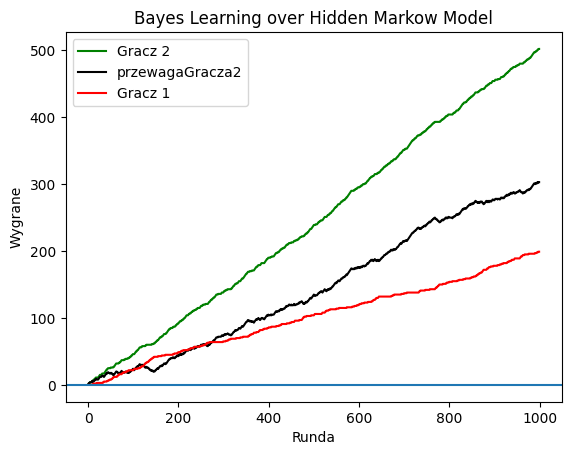

In [88]:
import matplotlib.pyplot as plt

#wyniki
winner = max(statistics, key = statistics.get)
print("wygral gracz", max(statistics, key=statistics.get))
print(statistics)

print(f"maciez 1 gracza: {transitionMatrix}")
print(f"maciez 2 gracza: {transitionCounts}")


#wykres
difference = [player2-player1 for player1, player2 in zip(wins1Forpyplot,wins2Forpyplot)]
plt.plot(wins2Forpyplot, label="Gracz 2", color="green")
plt.plot(difference, label = "przewagaGracza2", color = "black")
plt.plot(wins1Forpyplot, label="Gracz 1", color="red")
plt.axhline(0)

plt.title("Bayes Learning over Hidden Markow Model")
plt.xlabel("Runda")
plt.ylabel("Wygrane")
plt.legend()

plt.show()